In [1]:
import pandas as pd
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt 
import yaml
import os
import sys

plt.style.use("~/evanstyle.mplstyle") #replace with your own or comment


In [12]:
redfile_sig = "/Volumes/CodeDrive/Gamma_Data_7_16_24/reduced/6g24pt_sig/combined.p"
redfile_bk = "/Volumes/CodeDrive/Gamma_Data_7_16_24/reduced/6g24pt_bkg/combined.p"
#or on llnl
#redfile_sig = "/p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/reduced/6g24pt_sig/combined.p"
#redfile_bk = "/p/lustre1/nexouser/data/StanfordData/ChargeModule/LXe_Run1/Gamma_Data_7_16_24/reduced/6g24pt_bkg/combined.p"

df_sig = pickle.load(open(redfile_sig, "rb"))[0]
df_bk = pickle.load(open(redfile_bk, "rb"))[0]

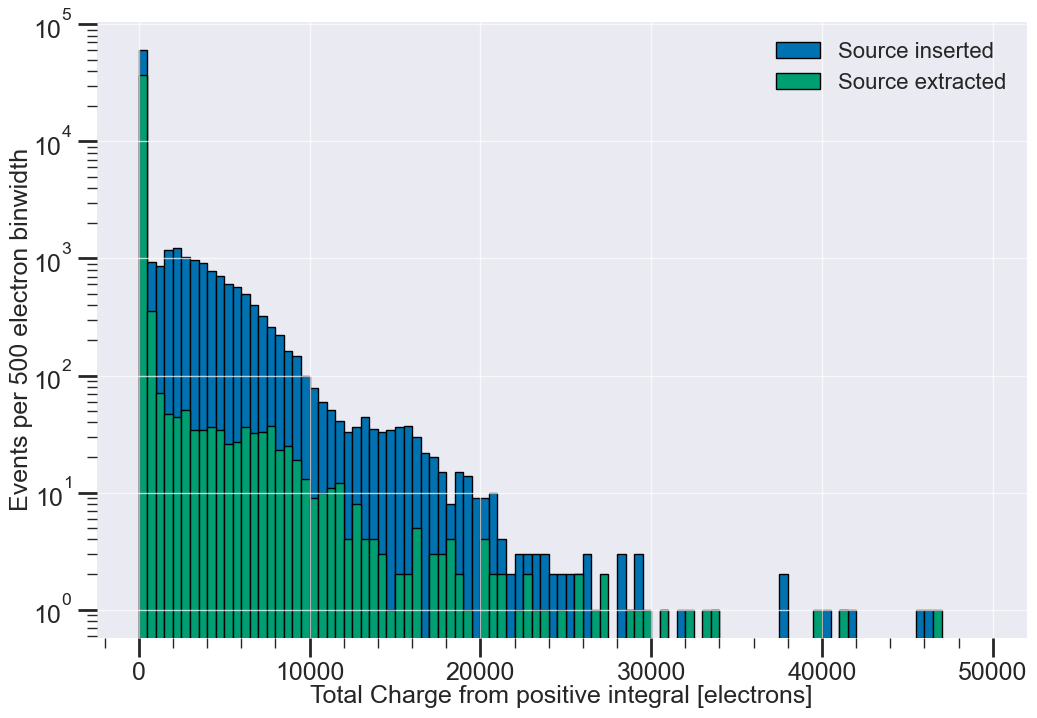

In [14]:
#example of how to slice for a basic quantity in the reducedquantities list. 

#most of the time you'll start by ignoring events with "None" (or accidentally NaN's, trying not to have those in the first place)
mask = (df_sig["total_charge"] != None)
hs = df_sig["total_charge"][mask]
#i like to control binwidth manually, which is why I use a separate "hs" variable
binwidth = 500 #electrons
bins = np.arange(np.min(hs), 50000, binwidth)
fig, ax = plt.subplots()
ax.hist(hs, bins=bins, label="Source inserted")

mask = (df_bk["total_charge"] != None)
hs = df_bk["total_charge"][mask]
#i like to control binwidth manually, which is why I use a separate "hs" variable
binwidth = 500 #electrons
ax.hist(hs, bins=bins, label="Source extracted")
ax.legend()

ax.set_xlabel("Total Charge from positive integral [electrons]")
ax.set_ylabel("Events per {:.0f} electron binwidth".format(binwidth))
ax.set_yscale('log')
plt.show()


In [10]:
#Integrals and pulse heights will be interesting to compare, but pulse heights are 
#stored within the pulse identified objects. so here we dip into those. 
#The value of each events "pulse" key is a list of dictionaries, where
#the dictionary contains information about the pulse, specifically those in the
#pulse section of the reduced quantities. 

#find events with non empty pulse lists
mask = (df_sig["n_pulses"] > 0)
pos_integrals = []
neg_integrals = []
maxs = []
mins = []
widths = []
for i, event in df_sig[mask].iterrows():
    for pulse in event["pulses"]:
        if(pulse["polarity"] == 1):
            pos_integrals.append(pulse["integral"])
            maxs.append(pulse["max"])
        if(pulse["polarity"] == -1):
            neg_integrals.append(pulse["integral"])
            mins.append(pulse["min"])

        if(pulse["width"] != None):
            widths.append(pulse["width"])


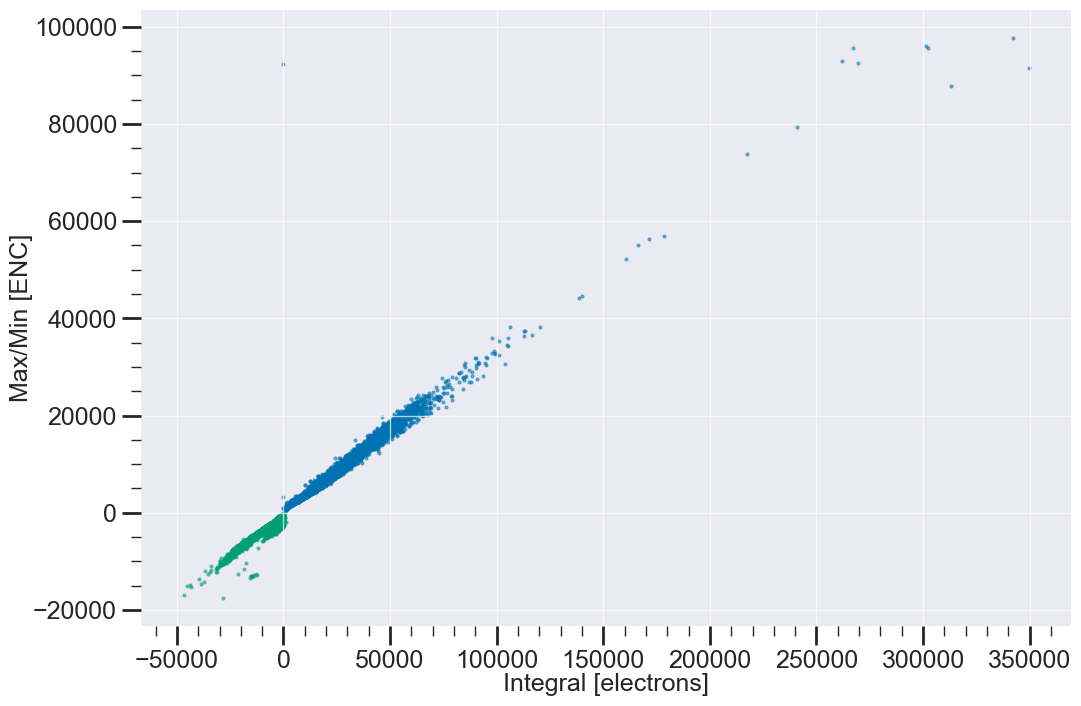

In [11]:
fig, ax = plt.subplots()
ax.scatter(pos_integrals, maxs, label="Positive Pulses", alpha=0.5)
ax.scatter(neg_integrals, mins, label="Negative Pulses", alpha=0.5)
ax.set_xlabel("Integral [electrons*us]")
ax.set_ylabel("Max/Min [electrons]")
plt.show()

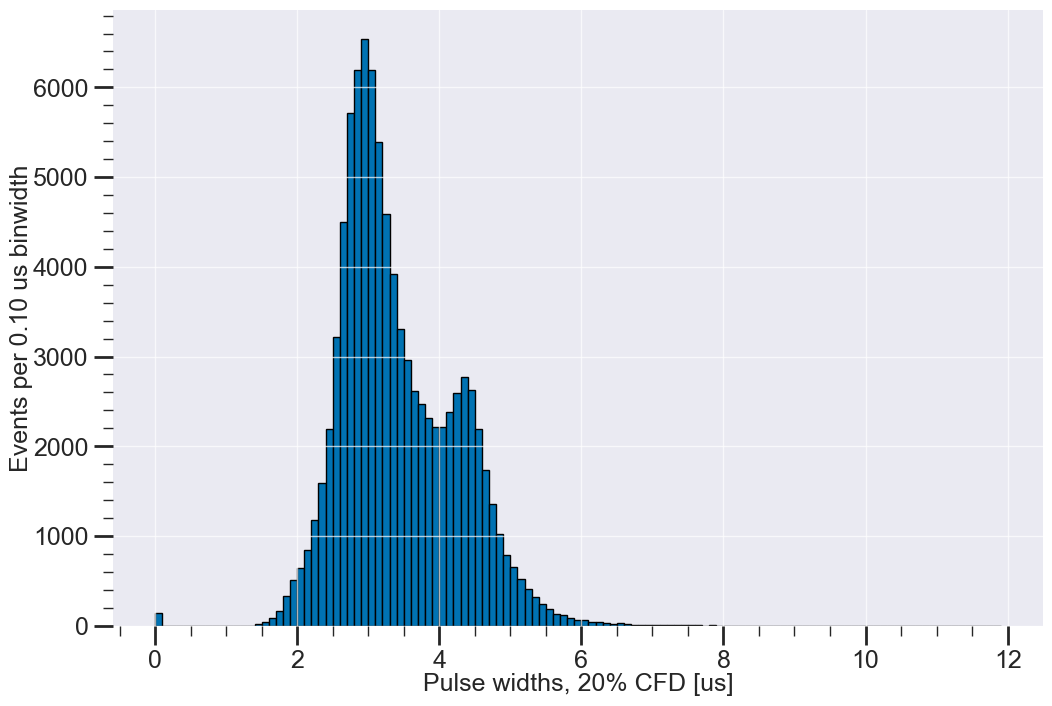

In [19]:

binwidth = 0.1 #us
bins = np.arange(0, 12, binwidth)
fig, ax = plt.subplots()
ax.hist(widths, bins=bins)
ax.set_xlabel("Pulse widths, 20% CFD [us]")
ax.set_ylabel("Events per {:.2f} us binwidth".format(binwidth))
plt.show()

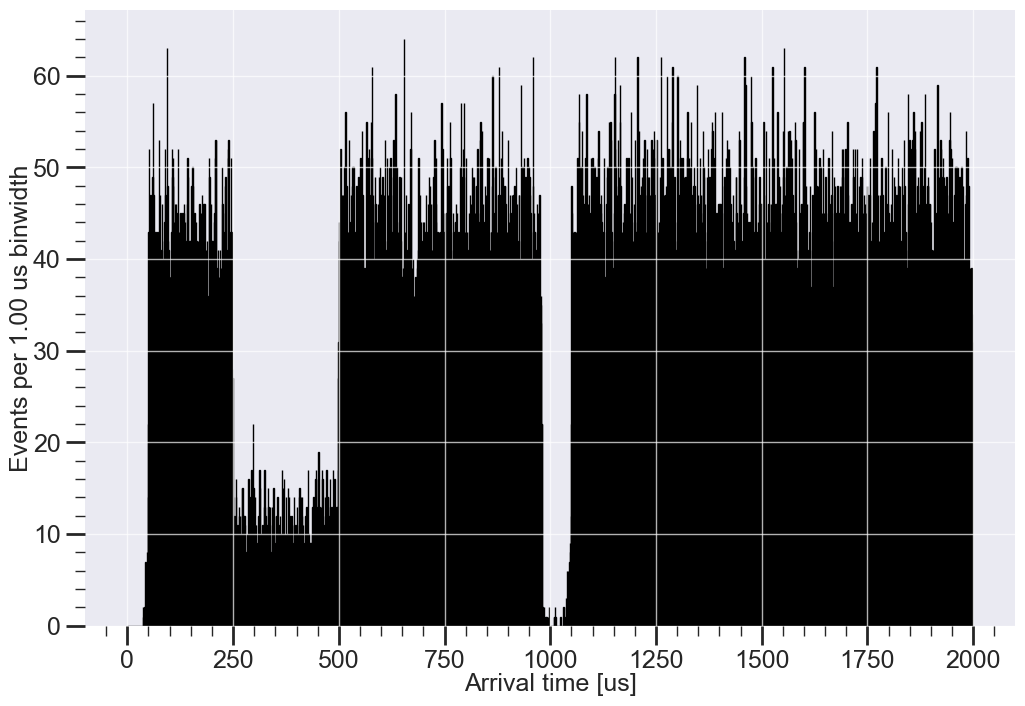

In [ ]:
#arrival times should be uniform
#BUT as you see in this plot (date is January 2025), the baseline region 
#has far fewer events than others. Could there be a baseline dependent
#bias on the pulse finding algorithm? (The other "key" is an ignored region)
mask = (df_sig["t"] != None)
hs = df_sig["t"][mask]
binwidth = 1 #us
bins = np.arange(0, 2000, binwidth)
fig, ax = plt.subplots()
ax.hist(hs, bins=bins)
ax.set_xlabel("Arrival time [us]")
ax.set_ylabel("Events per {:.2f} us binwidth".format(binwidth))
plt.show()


In [31]:

#waveform level data is also available, and sometimes useful to have channel map
def load_config(config):
    with open(config, 'r') as stream:
        try:
            config = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)


    #now that the config is loaded, load the channel map file that
    #is referenced in the config. Check if it exists
    if(os.path.isfile(config["chmap"]) == False):
        print("Cant find the channel map file: " + str(config["chmap"]))
        chmap = None
        return 

    with open(config["chmap"], 'r') as stream:
            try:
                chmap = yaml.safe_load(stream)
            except yaml.YAMLError as exc:
                print(exc)

    return config, chmap

config, chmap = load_config("../config/gamma-post-surg-24.yml")

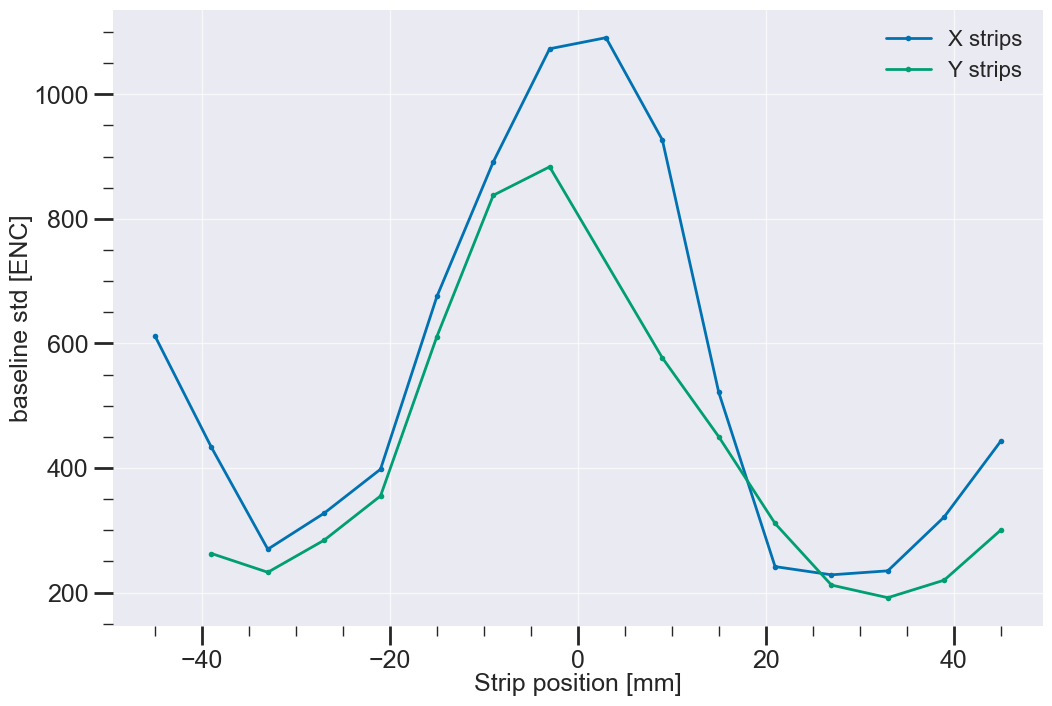

In [38]:
sys.path.append("../")
import Utilities as Util
    
chs = range(63)
xchs = [ch for ch in chs if Util.get_channel_type(chmap, ch) == "x" and ch not in config["dead_channels"]]
ychs = [ch for ch in chs if Util.get_channel_type(chmap, ch) == "y" and ch not in config["dead_channels"]]
dchs = [ch for ch in chs if Util.get_channel_type(chmap, ch) == "dummy" and ch not in config["dead_channels"]]
fig, ax = plt.subplots()

pos = [Util.get_channel_pos(chmap, ch)[1] for ch in xchs]
stds = []
for ch in xchs:
    stds.append(np.mean(np.array(df_bk["ch{:d} baseline_std".format(ch)])))

#sort both simultaneously
pos, stds = zip(*sorted(zip(pos, stds)))
ax.plot(pos, stds, 'o-', label="X strips")

pos = [Util.get_channel_pos(chmap, ch)[0] for ch in ychs]
stds = []
for ch in ychs:
    stds.append(np.mean(np.array(df_bk["ch{:d} baseline_std".format(ch)])))

#sort both simultaneously
pos, stds = zip(*sorted(zip(pos, stds)))
ax.plot(pos, stds, 'o-', label="Y strips")
ax.legend()
ax.set_xlabel("Strip position [mm]")
ax.set_ylabel("baseline std [ENC]")
plt.show()
    

In [43]:
#finally, take a look at how many pulses are in each cluster
mask = (df_sig["n_clusters"] > 0)
cluster_mult = []
q = []
for i, event in df_sig[mask].iterrows():
    for cluster in event["clusters"]:
        cluster_mult.append(cluster["n_pulses"])
        q.append(cluster["q"])



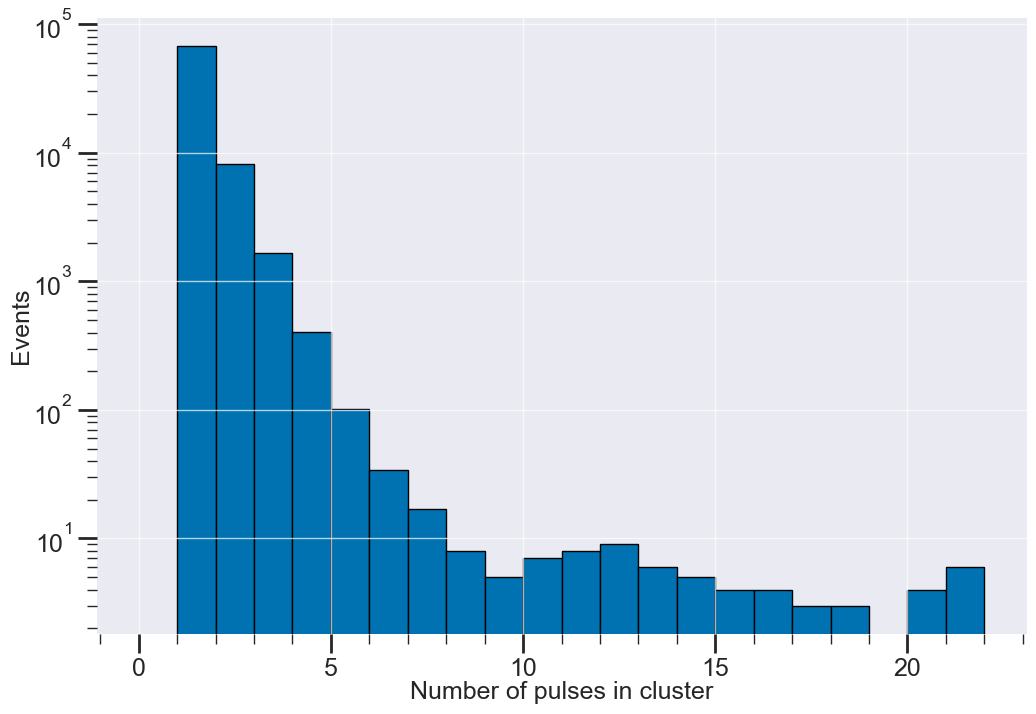

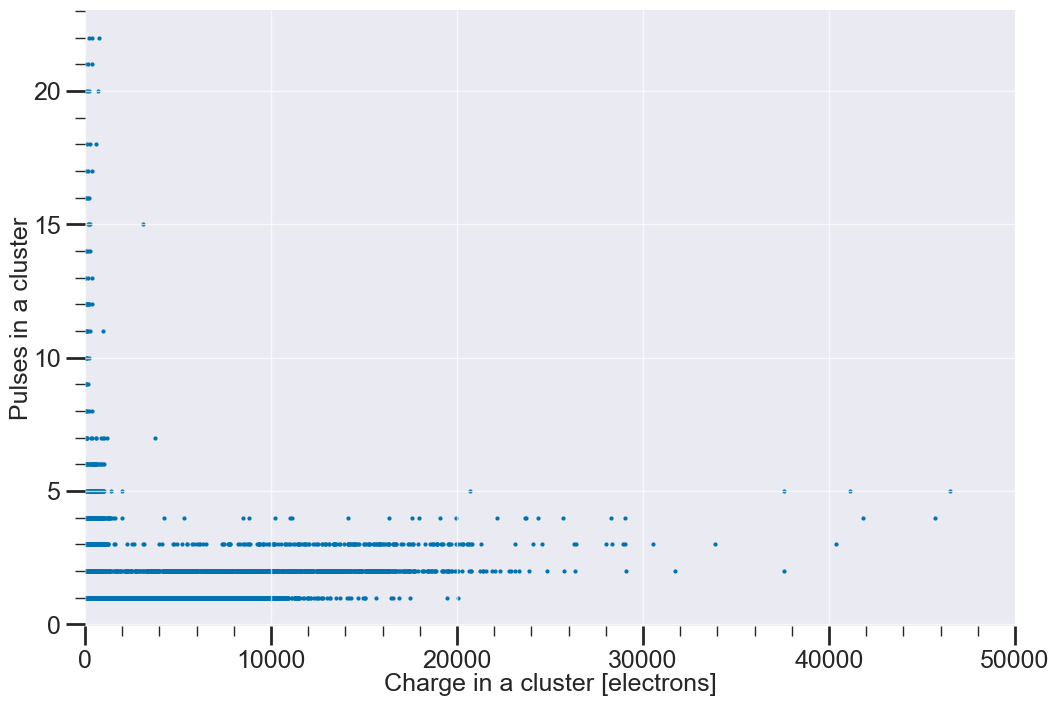

In [45]:
fig, ax = plt.subplots()
ax.hist(cluster_mult, bins=range(0, max(cluster_mult)+1))
ax.set_xlabel("Number of pulses in cluster")
ax.set_ylabel("Events")
ax.set_yscale('log')
plt.show()

fig, ax = plt.subplots()
ax.scatter(q, cluster_mult)
ax.set_xlabel("Charge in a cluster [electrons]")
ax.set_ylabel("Pulses in a cluster")
ax.set_xlim([0, 50000])
plt.show()